In [2]:
import sys
import spikeinterface as si
import matplotlib.pyplot as plt
import spikeinterface.extractors as se
import spikeinterface.preprocessing as spre
import spikeinterface.sorters as ss
import spikeinterface.widgets as sw
import spikeinterface.qualitymetrics as sqm
import json
import probeinterface

from probeinterface import Probe, ProbeGroup

import os
import numpy as np
from spikeinterface.core import concatenate_recordings

import warnings
warnings.filterwarnings('ignore')
import pandas as pd
from matplotlib.backends.backend_pdf import PdfPages
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from scipy.stats import pearsonr
import pandas as pd
import numpy as np
from matplotlib.collections import LineCollection
from probeinterface import write_probeinterface, read_probeinterface, Probe
from scipy.io import loadmat


probe_data = loadmat("/media/ubuntu/sda/duan/rat/probe/chanMapQPX_mice1.mat")
probe_x = probe_data['xcoords']
probe_y = probe_data['ycoords']

probe_position = pd.DataFrame(probe_x)
probe_position[1] = probe_y

probe = Probe()
probe.set_contacts(positions=probe_position, contact_ids=probe_data['chanMap'][:, 0])


probe.set_device_channel_indices(range(128))



In [49]:
import sys
import spikeinterface as si
import matplotlib.pyplot as plt
import spikeinterface.extractors as se
import spikeinterface.preprocessing as spre
import spikeinterface.sorters as ss
import spikeinterface.widgets as sw
import spikeinterface.qualitymetrics as sqm
import json
import probeinterface

from probeinterface import Probe, ProbeGroup

import os
import numpy as np
from spikeinterface.core import concatenate_recordings

import warnings
warnings.filterwarnings('ignore')
import pandas as pd
from matplotlib.backends.backend_pdf import PdfPages
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from scipy.stats import pearsonr
import pandas as pd
import numpy as np
from matplotlib.collections import LineCollection
from probeinterface import write_probeinterface, read_probeinterface, Probe
from scipy.io import loadmat


probe_data = loadmat("/media/ubuntu/sda/duan/raw_data/chanMap_DCX_5mm.mat")
probe_x = probe_data['xcoords']
probe_y = probe_data['ycoords']

probe_position = pd.DataFrame(probe_x)
probe_position[1] = probe_y

probe = Probe()

probe_loc = pd.read_csv('/media/ubuntu/sda/duan/raw_data/ch_map_R.csv')
probe.set_contacts(positions=probe_position, contact_ids=probe_loc['probeloc'].values)

probe.set_device_channel_indices(range(256))

In [52]:
recording_raw = se.read_binary('/media/ubuntu/sda/duan/raw_data/recording_slice.bin', sampling_frequency=30000, dtype=np.int16, num_channels=256)
recording_raw = recording_raw.rename_channels(['A-000', 'A-001', 'A-002', 'A-003', 'A-004', 'A-005', 'A-006',
       'A-007', 'A-008', 'A-009', 'A-010', 'A-011', 'A-012', 'A-013',
       'A-014', 'A-015', 'A-016', 'A-017', 'A-018', 'A-019', 'A-020',
       'A-021', 'A-022', 'A-023', 'A-024', 'A-025', 'A-026', 'A-027',
       'A-028', 'A-029', 'A-030', 'A-031', 'A-032', 'A-033', 'A-034',
       'A-035', 'A-036', 'A-037', 'A-038', 'A-039', 'A-040', 'A-041',
       'A-042', 'A-043', 'A-044', 'A-045', 'A-046', 'A-047', 'A-048',
       'A-049', 'A-050', 'A-051', 'A-052', 'A-053', 'A-054', 'A-055',
       'A-056', 'A-057', 'A-058', 'A-059', 'A-060', 'A-061', 'A-062',
       'A-063', 'A-064', 'A-065', 'A-066', 'A-067', 'A-068', 'A-069',
       'A-070', 'A-071', 'A-072', 'A-073', 'A-074', 'A-075', 'A-076',
       'A-077', 'A-078', 'A-079', 'A-080', 'A-081', 'A-082', 'A-083',
       'A-084', 'A-085', 'A-086', 'A-087', 'A-088', 'A-089', 'A-090',
       'A-091', 'A-092', 'A-093', 'A-094', 'A-095', 'A-096', 'A-097',
       'A-098', 'A-099', 'A-100', 'A-101', 'A-102', 'A-103', 'A-104',
       'A-105', 'A-106', 'A-107', 'A-108', 'A-109', 'A-110', 'A-111',
       'A-112', 'A-113', 'A-114', 'A-115', 'A-116', 'A-117', 'A-118',
       'A-119', 'A-120', 'A-121', 'A-122', 'A-123', 'A-124', 'A-125',
       'A-126', 'A-127', 'B-000', 'B-001', 'B-002', 'B-003', 'B-004',
       'B-005', 'B-006', 'B-007', 'B-008', 'B-009', 'B-010', 'B-011',
       'B-012', 'B-013', 'B-014', 'B-015', 'B-016', 'B-017', 'B-018',
       'B-019', 'B-020', 'B-021', 'B-022', 'B-023', 'B-024', 'B-025',
       'B-026', 'B-027', 'B-028', 'B-029', 'B-030', 'B-031', 'B-032',
       'B-033', 'B-034', 'B-035', 'B-036', 'B-037', 'B-038', 'B-039',
       'B-040', 'B-041', 'B-042', 'B-043', 'B-044', 'B-045', 'B-046',
       'B-047', 'B-048', 'B-049', 'B-050', 'B-051', 'B-052', 'B-053',
       'B-054', 'B-055', 'B-056', 'B-057', 'B-058', 'B-059', 'B-060',
       'B-061', 'B-062', 'B-063', 'B-064', 'B-065', 'B-066', 'B-067',
       'B-068', 'B-069', 'B-070', 'B-071', 'B-072', 'B-073', 'B-074',
       'B-075', 'B-076', 'B-077', 'B-078', 'B-079', 'B-080', 'B-081',
       'B-082', 'B-083', 'B-084', 'B-085', 'B-086', 'B-087', 'B-088',
       'B-089', 'B-090', 'B-091', 'B-092', 'B-093', 'B-094', 'B-095',
       'B-096', 'B-097', 'B-098', 'B-099', 'B-100', 'B-101', 'B-102',
       'B-103', 'B-104', 'B-105', 'B-106', 'B-107', 'B-108', 'B-109',
       'B-110', 'B-111', 'B-112', 'B-113', 'B-114', 'B-115', 'B-116',
       'B-117', 'B-118', 'B-119', 'B-120', 'B-121', 'B-122', 'B-123',
       'B-124', 'B-125', 'B-126', 'B-127'])

In [58]:
recording_raw = spre.resample(recording_raw, 10000)
recording_recorded = spre.bandpass_filter(recording_raw, freq_min=300, freq_max=3000)
recording_recorded = spre.notch_filter(recording_recorded, freq=50)
recording_f = spre.common_reference(recording_recorded, reference="global", operator="median")

recording_f = recording_f.set_probegroup(probe)

In [60]:
ss.get_default_sorter_params('kilosort4')

{'fs': 30000,
 'batch_size': 60000,
 'nblocks': 1,
 'Th_universal': 9,
 'Th_learned': 8,
 'nt': 61,
 'shift': None,
 'scale': None,
 'artifact_threshold': inf,
 'nskip': 25,
 'whitening_range': 32,
 'highpass_cutoff': 300,
 'binning_depth': 5,
 'sig_interp': 20,
 'drift_smoothing': [0.5, 0.5, 0.5],
 'nt0min': None,
 'dmin': None,
 'dminx': 32,
 'min_template_size': 10,
 'template_sizes': 5,
 'nearest_chans': 10,
 'nearest_templates': 100,
 'max_channel_distance': 32,
 'max_peels': 100,
 'templates_from_data': True,
 'n_templates': 6,
 'n_pcs': 6,
 'Th_single_ch': 6,
 'acg_threshold': 0.2,
 'ccg_threshold': 0.25,
 'cluster_neighbors': 10,
 'cluster_downsampling': 1,
 'max_cluster_subset': 25000,
 'x_centers': None,
 'duplicate_spike_ms': 0.25,
 'position_limit': 100,
 'do_CAR': True,
 'invert_sign': False,
 'save_extra_vars': False,
 'save_preprocessed_copy': False,
 'torch_device': 'auto',
 'bad_channels': None,
 'clear_cache': False,
 'do_correction': True,
 'skip_kilosort_preprocessi

In [ ]:
output_folder = f'/media/ubuntu/sda/duan/result/251205_test_3'
os.makedirs(output_folder, exist_ok=True)

sorting_kilosort4 = ss.run_sorter(sorter_name="kilosort4", recording=recording_f, folder=output_folder + "/kilosort4")
analyzer_kilosort4 = si.create_sorting_analyzer(sorting=sorting_kilosort4, recording=recording_f, format='binary_folder', folder=output_folder + '/analyzer_kilosort4_binary')

extensions_to_compute = [
    "random_spikes",
    "waveforms",
    "noise_levels",
    "templates",
    "spike_amplitudes",
    "unit_locations",
    "spike_locations",
    "correlograms",
    "template_similarity"
]

extension_params = {
    "unit_locations": {"method": "center_of_mass"},
    "spike_locations": {"ms_before": 0.1},
    "correlograms": {"bin_ms": 0.1},
    "template_similarity": {"method": "cosine_similarity"}
}

analyzer_kilosort4.compute(extensions_to_compute, extension_params=extension_params)

qm_params = sqm.get_default_qm_params()
analyzer_kilosort4.compute("quality_metrics", qm_params)

import spikeinterface.exporters as sexp
sexp.export_to_phy(analyzer_kilosort4, output_folder + "/phy_folder_for_kilosort", verbose=True)

KeyboardInterrupt: 

In [3]:
recording_raw = se.read_binary('/home/ubuntu/Downloads/paper/20250615_1.group0.bin', sampling_frequency=30000, dtype=np.int16, num_channels=128*7)
recording_recorded = spre.bandpass_filter(recording_raw, freq_min=300, freq_max=3000)
recording_recorded = spre.notch_filter(recording_recorded, freq=50)
recording_f = spre.common_reference(recording_recorded, reference="global", operator="median")


In [7]:
trace0_car = a.get_traces(start_frame=0, end_frame=10 * 30000, ).astype(np.float32)


In [8]:
trace0_car.shape

(300000, 11)

<Axes: >

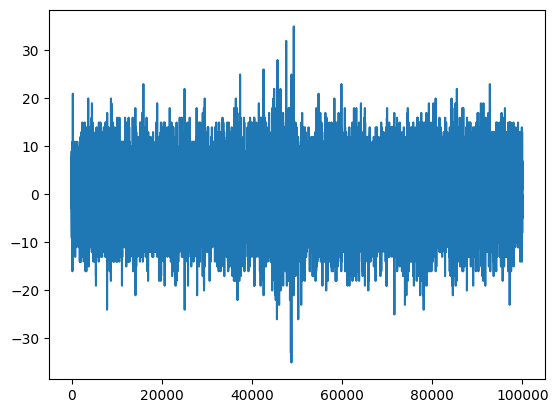

In [15]:
import seaborn as sns
sns.lineplot(trace0_car[:100000, 5])

In [3]:
a = recording_f.get_traces(0, 10, channel_ids = [0])

: 

: 

In [2]:
recording_raw = se.read_binary('/home/ubuntu/Downloads/paper/20250615_1.group0.bin', sampling_frequency=30000, dtype=np.int16, num_channels=128*7)
recording_list = []

for i in range(7):
    recording_list.append(recording_raw.select_channels([channel + 128*i for channel in range(128)]))


for i in [0, 1, 2, 3]:
    recording_recorded = spre.bandpass_filter(recording_list[i], freq_min=300, freq_max=3000)
    recording_recorded = spre.notch_filter(recording_recorded, freq=50)
    recording_f = spre.common_reference(recording_recorded, reference="global", operator="median")

    recording_f = recording_f.set_probegroup(probe)
    recording_preprocessed = recording_f.save(format="binary")

    output_folder = f'/media/ubuntu/sda/duan/rat/sorting_results/day4/probe_{i+1}'
    os.makedirs(output_folder, exist_ok=True)

    sorting_kilosort4 = ss.run_sorter(sorter_name="kilosort4", recording=recording_preprocessed, folder=output_folder + "/kilosort4")
    analyzer_kilosort4 = si.create_sorting_analyzer(sorting=sorting_kilosort4, recording=recording_preprocessed, format='binary_folder', folder=output_folder + '/analyzer_kilosort4_binary')

    extensions_to_compute = [
        "random_spikes",
        "waveforms",
        "noise_levels",
        "templates",
        "spike_amplitudes",
        "unit_locations",
        "spike_locations",
        "correlograms",
        "template_similarity"
    ]

    extension_params = {
        "unit_locations": {"method": "center_of_mass"},
        "spike_locations": {"ms_before": 0.1},
        "correlograms": {"bin_ms": 0.1},
        "template_similarity": {"method": "cosine_similarity"}
    }

    analyzer_kilosort4.compute(extensions_to_compute, extension_params=extension_params)

    qm_params = sqm.get_default_qm_params()
    analyzer_kilosort4.compute("quality_metrics", qm_params)

    import spikeinterface.exporters as sexp
    sexp.export_to_phy(analyzer_kilosort4, output_folder + "/phy_folder_for_kilosort", verbose=True)
    

AttributeError: module 'spikeinterface.extractors' has no attribute 'read_binary'

In [33]:
recording_raw = se.read_binary('/home/ubuntu/Downloads/paper/20250624_1.group0.bin', sampling_frequency=30000, dtype=np.int16, num_channels=128*7)
recording_list = []

for i in range(7):
    recording_list.append(recording_raw.select_channels([channel + 128*i for channel in range(128)]))


for i in range(7):
    recording_recorded = spre.bandpass_filter(recording_list[i], freq_min=300, freq_max=3000)
    recording_recorded = spre.notch_filter(recording_recorded, freq=50)
    recording_f = spre.common_reference(recording_recorded, reference="global", operator="median")

    recording_f = recording_f.set_probegroup(probe)
    recording_preprocessed = recording_f.save(format="binary")

    output_folder = f'/media/ubuntu/sda/duan/rat/sorting_results/day13/probe_{i+1}'
    os.makedirs(output_folder, exist_ok=True)

    sorting_kilosort4 = ss.run_sorter(sorter_name="kilosort4", recording=recording_preprocessed, folder=output_folder + "/kilosort4")
    analyzer_kilosort4 = si.create_sorting_analyzer(sorting=sorting_kilosort4, recording=recording_preprocessed, format='binary_folder', folder=output_folder + '/analyzer_kilosort4_binary')

    extensions_to_compute = [
        "random_spikes",
        "waveforms",
        "noise_levels",
        "templates",
        "spike_amplitudes",
        "unit_locations",
        "spike_locations",
        "correlograms",
        "template_similarity"
    ]

    extension_params = {
        "unit_locations": {"method": "center_of_mass"},
        "spike_locations": {"ms_before": 0.1},
        "correlograms": {"bin_ms": 0.1},
        "template_similarity": {"method": "cosine_similarity"}
    }

    analyzer_kilosort4.compute(extensions_to_compute, extension_params=extension_params)

    qm_params = sqm.get_default_qm_params()
    analyzer_kilosort4.compute("quality_metrics", qm_params)

    import spikeinterface.exporters as sexp
    sexp.export_to_phy(analyzer_kilosort4, output_folder + "/phy_folder_for_kilosort", verbose=True)

Use cache_folder=/tmp/spikeinterface_cache/tmpp_2nvqyz/XP8KCJV8
write_binary_recording 
engine=process - n_jobs=1 - samples_per_chunk=30,000 - chunk_memory=7.32 MiB - total_memory=7.32 MiB - chunk_duration=1.00s


estimate_sparsity (no parallelization): 100%|██████████| 915/915 [00:00<00:00, 16204.96it/s]


create_sorting_analyzer: recording does not have scaling to uV, forcing return_in_uV=False


noise_level (no parallelization): 100%|██████████| 20/20 [00:00<00:00, 33.98it/s]
Compute : spike_amplitudes + spike_locations (no parallelization): 100%|██████████| 915/915 [00:15<00:00, 57.88it/s]
extract PCs (no parallelization): 100%|██████████| 915/915 [15:07<00:00,  1.01it/s]


Run:
phy template-gui  /media/ubuntu/sda/duan/rat/sorting_results/day13/probe_1/phy_folder_for_kilosort/params.py
Use cache_folder=/tmp/spikeinterface_cache/tmphz82j554/253CLR1D
write_binary_recording 
engine=process - n_jobs=1 - samples_per_chunk=30,000 - chunk_memory=7.32 MiB - total_memory=7.32 MiB - chunk_duration=1.00s


...

Run:
phy template-gui  /media/ubuntu/sda/duan/rat/sorting_results/day13/probe_6/phy_folder_for_kilosort/params.py
Use cache_folder=/tmp/spikeinterface_cache/tmpx7x1kaeq/DBILC21Q
write_binary_recording 
engine=process - n_jobs=1 - samples_per_chunk=30,000 - chunk_memory=7.32 MiB - total_memory=7.32 MiB - chunk_duration=1.00s


estimate_sparsity (no parallelization): 100%|██████████| 915/915 [00:00<00:00, 14483.31it/s]


create_sorting_analyzer: recording does not have scaling to uV, forcing return_in_uV=False


noise_level (no parallelization): 100%|██████████| 20/20 [00:00<00:00, 35.07it/s]
Compute : spike_amplitudes + spike_locations (no parallelization): 100%|██████████| 915/915 [00:12<00:00, 70.96it/s]
extract PCs (no parallelization): 100%|██████████| 915/915 [15:56<00:00,  1.05s/it]

Run:
phy template-gui  /media/ubuntu/sda/duan/rat/sorting_results/day13/probe_7/phy_folder_for_kilosort/params.py
